# video 처럼 다루어 보자

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim
import rasterio
import copy
import torch.nn.init as init

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### train, eval 함수 정의 (Naive ver과 동일)

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = model.state_dict()  # 초기 모델 가중치 저장
    no_improve_count = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)  # 배치별 loss * 개수로 전체 손실 계산
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)  # 전체 샘플 수로 나눔
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"\nEpoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%\n")

        # Early Stopping & Model Saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break
    
    return best_model_state, train_losses, val_losses


In [4]:
target_name_mapping = {
    0: "Non-Forest", #비산림
    1: "Pine", #소나무
    2: "Nut Pine", #잣나무
    3: "Larch", #낙엽송
    4: "Pitch Pine", #리기다 소나무
    5: "Oak", #상수리나무
    6: "Mongolian Oak", #신갈나무
    7: "Oriental Oak" #굴참나무
}

def evaluate_model_with_cm(model, val_loader, num_classes=8, target_name_mapping=target_name_mapping):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  
            all_predictions.extend(predicted.cpu().numpy())  

    # 모든 클래스 목록 (0 ~ num_classes-1)
    full_class_labels = np.arange(num_classes)

    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=full_class_labels)

    # Confusion Matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_name_mapping.values(), yticklabels=target_name_mapping.values())
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Classification Report
    target_names = list(target_name_mapping.values())
    report = classification_report(all_labels, all_predictions, labels=full_class_labels, target_names=target_names, digits=3)

    print("Classification Report:")
    print(report)


### Dataset 클래스 정의 (Naive ver과 동일)

In [5]:
class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=3, box_filter_fn=None, transform=None):
        """
        Args:
            large_tif_dir (str): 여러 개의 큰 TIFF 파일이 저장된 디렉토리 경로.
            file_list (list of str): 처리할 원천 데이터 파일명 리스트.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 ("file", "x_pos", "y_pos", "label" 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (항상 홀수여야 함).
            box_filter_fn (callable, optional): 박스 번호 필터링 함수.
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        if patch_size % 2 == 0:
            raise ValueError("patch_size는 홀수여야 합니다.")

        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        # 박스 필터 함수 설정 (기본값: 모든 박스 사용)
        self.box_filter_fn = box_filter_fn or (lambda box_number: True)

        # 파일명 필터링: file_list에 있는 파일만 유지
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)

        # 박스 번호 필터링
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.half_size = patch_size // 2  # 패치의 반 크기
        self.transform = transform

        # 각 파일명을 키로 하고 이미지를 값으로 가지는 딕셔너리
        self.image_cache = {}

    def _load_image(self, file_name):
        """파일 이름에 해당하는 이미지를 로드하여 캐시에 저장."""
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 현재 인덱스에 해당하는 데이터 가져오기
        row = self.label_df.iloc[idx]
        file_name = row["file"]
        x, y = row["x_pos"], row["y_pos"]
        label = row["label"]

        # 이미지 로드
        image = self._load_image(file_name)
        image_height, image_width = image.shape[:2]

        # 중심 좌표 기준으로 패치의 좌상단 좌표 계산
        x_start = x - self.half_size
        y_start = y - self.half_size
        x_end = x + self.half_size + 1  # 슬라이싱할 범위는 [start:end]
        y_end = y + self.half_size + 1

        # 범위 검사
        if x_start < 0 or y_start < 0 or x_end > image_width or y_end > image_height:
            raise ValueError(f"Patch centered at (x={x}, y={y}) exceeds bounds of image '{file_name}'.")

        # 이미지 슬라이싱
        patch = image[y_start:y_end, x_start:x_end]

        # 전처리 적용
        if self.transform:
            patch = self.transform(patch)

        return patch, label


### 테스트지역 선별 (Naive ver과 동의)

In [6]:
# 테스트 필터 정의
test_filter = lambda box_number: (box_number % 9 == 0 or box_number % 9 == 5)

### 데이터 전처리 방법 설정

In [7]:
class ReshapeTransform:
    """(12*bands, 3, 3) → (12, bands, 3, 3) 변환"""
    def __init__(self, bands):
        self.bands = bands

    def __call__(self, x):
        return x.view(12, self.bands, 3, 3).permute(1, 0, 2, 3)

def get_transform(bands, scale_channels_func=None):
    transform_list = [
        transforms.ToTensor(),  # (H, W, C) → (C, H, W)
        transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
        ReshapeTransform(bands)  # (12*bands, 3, 3) → (bands, 12, 3, 3)
    ]

    if scale_channels_func:
        transform_list.append(transforms.Lambda(scale_channels_func))  # 채널별 값 조정 추가

    return transforms.Compose(transform_list)

#scaling 함수 - 채널별로 범위의 차이가 크기때문에 어느정도 맞추어주기 위해서 수행
def scale_channels(x):
    """특정 채널값 조정"""
    x[0:3] *= 5  # B,G,R 채널 * 5
    if 4 < x.shape[0]:
        x[4] *= 0.5  # NDVI 채널 * 0.5
    return x

### 2 + 1 CNN이용한 단순한 resnet 모델

In [8]:
# SwigLU 활성 함수 정의 (SiLU 변형)
class SwigLU(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(1.3 * x)

# 2+1D 컨볼루션 블록: 공간과 시간 축을 분리하여 컨볼루션 수행
class Conv2Plus1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3,3), stride=1, padding=1):
        super().__init__()
        mid_channels = out_channels  # 중간 채널 수 설정
        
        # 공간 차원에 대한 2D 컨볼루션
        self.spatial_conv = nn.Conv3d(in_channels, mid_channels, kernel_size=(1, kernel_size[1], kernel_size[2]), 
                                      stride=(1, stride, stride), padding=(0, padding, padding), bias=False)
        self.bn1 = nn.BatchNorm3d(mid_channels)
        
        # 시간 차원에 대한 1D 컨볼루션
        self.temporal_conv = nn.Conv3d(mid_channels, out_channels, kernel_size=(kernel_size[0], 1, 1), 
                                       stride=(stride, 1, 1), padding=(padding, 0, 0), bias=False)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.spatial_conv(x)))
        x = self.relu(self.bn2(self.temporal_conv(x)))
        return x

# ResNet 스타일의 기본 블록 (Skip Connection 포함)
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = Conv2Plus1D(channels, channels)
        self.conv2 = Conv2Plus1D(channels, channels)
        self.bn = nn.BatchNorm3d(channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        residual = x  # 원본 입력 저장
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn(x)
        return self.relu(x + residual)  # Skip Connection 적용

# 밴드(채널) 확장 블록: 1x1 컨볼루션 사용
class BandExpansion(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

# 피드포워드 블록: SwigLU 활성 함수와 확장 비율 적용
class FeedForward(nn.Module):
    def __init__(self, channels, expand_ratio=2):
        super().__init__()
        hidden_dim = channels * expand_ratio  # 확장된 채널 크기
        self.fc1 = nn.Conv3d(channels, hidden_dim, kernel_size=1)
        self.act = SwigLU()
        self.fc2 = nn.Conv3d(hidden_dim, channels, kernel_size=1)
        self.bn = nn.BatchNorm3d(channels)
    
    def forward(self, x):
        return self.bn(self.fc2(self.act(self.fc1(x))))

# 전체 비디오 분류 모델
class VideoClassifier(nn.Module):
    def __init__(self, input_bands, stage_repeats, stage_channels, num_classes=8):
        super().__init__()
        
        # 초기 밴드 확장 (입력 밴드 수 -> 첫 번째 stage 채널 크기)
        self.initial_conv = BandExpansion(input_bands, stage_channels[0])
        
        self.stages = nn.ModuleList()
        in_channels = stage_channels[0]
        
        # 4개의 Stage 구성
        for stage_idx in range(4):
            # 기본 ResBlock 반복 적용
            blocks = [ResBlock(in_channels) for _ in range(stage_repeats[stage_idx])]
            self.stages.append(nn.Sequential(*blocks))
            
            # 마지막 Stage를 제외하고 밴드 확장 수행
            if stage_idx < 3:
                self.stages.append(BandExpansion(in_channels, stage_channels[stage_idx + 1]))
                in_channels = stage_channels[stage_idx + 1]
        
        # 글로벌 평균 풀링 적용 (공간 차원 제거)
        self.gap = nn.AdaptiveAvgPool3d(1)
        
        # 피드포워드 블록 2개 추가
        self.ff1 = FeedForward(in_channels)
        self.ff2 = FeedForward(in_channels)
        
        # 최종 분류기 (Linear 레이어)
        self.classifier = nn.Linear(in_channels, num_classes)
        
    def forward(self, x):
        x = self.initial_conv(x)  # 초기 밴드 확장 적용
        
        # Stage 반복 수행
        for stage in self.stages:
            x = stage(x)
        
        # 글로벌 평균 풀링 적용 후 차원 축소
        x = self.gap(x).view(x.size(0), -1)
        
        # 피드포워드 블록 두 개 통과
        x = self.ff1(x.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1))
        x = self.ff2(x)
        
        # 최종 분류기 적용
        x = self.classifier(x.squeeze(-1).squeeze(-1).squeeze(-1))
        return x


### He 초기화 사용

In [9]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Conv3d):
        init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')  # He 초기화 적용
        if m.bias is not None:
            init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')  # 선형 레이어에도 Kaiming 초기화 적용
        if m.bias is not None:
            init.zeros_(m.bias)


## B, G, R, NIR 사용

In [10]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive" #원천데이터 주소
bands = 4 #밴드 수

transform = get_transform(bands, scale_channels)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [11]:
input_channels = 4  # Number of input bands
stage_repeats = [2, 3, 5, 2]  # Stage 3이 가장 깊음
stage_channels = [8, 16, 32, 48]  # 점진적으로 증가
model = VideoClassifier(input_channels, stage_repeats, stage_channels, num_classes=8)

model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [12]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video2_30.pth")

Epoch 1/30 - Validation: 100%|██████████| 1169/1169 [00:55<00:00, 20.95it/s]



Epoch [1/30], Train Loss: 0.7731, Train Accuracy: 70.78%, Val Loss: 0.6321, Val Accuracy: 76.65%



Epoch 2/30 - Validation: 100%|██████████| 1169/1169 [00:51<00:00, 22.87it/s]



Epoch [2/30], Train Loss: 0.5383, Train Accuracy: 80.47%, Val Loss: 0.6297, Val Accuracy: 76.55%



Epoch 3/30 - Validation: 100%|██████████| 1169/1169 [00:51<00:00, 22.86it/s]


...


Epoch [28/30], Train Loss: 0.1881, Train Accuracy: 93.29%, Val Loss: 0.5970, Val Accuracy: 83.32%



Epoch 29/30 - Validation: 100%|██████████| 1169/1169 [00:37<00:00, 31.38it/s]



Epoch [29/30], Train Loss: 0.1871, Train Accuracy: 93.29%, Val Loss: 0.6062, Val Accuracy: 82.78%



Epoch 30/30 - Validation: 100%|██████████| 1169/1169 [00:44<00:00, 26.10it/s]


Epoch [30/30], Train Loss: 0.1842, Train Accuracy: 93.36%, Val Loss: 0.5193, Val Accuracy: 85.03%



### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [02:31<00:00, 24.60it/s]


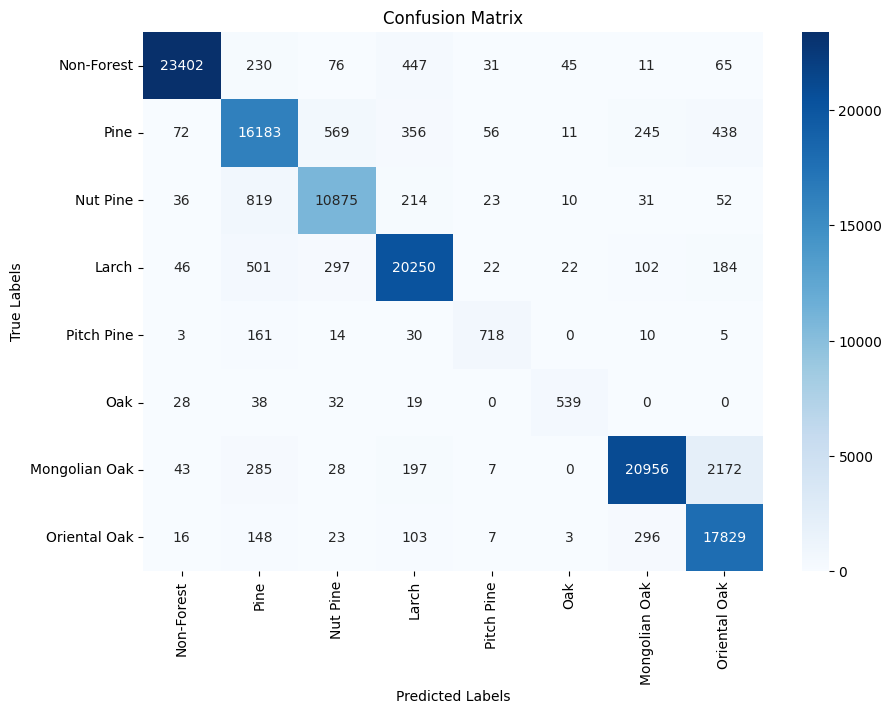

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.990     0.963     0.976     24307
         Pine      0.881     0.903     0.892     17930
     Nut Pine      0.913     0.902     0.907     12060
        Larch      0.937     0.945     0.941     21424
   Pitch Pine      0.831     0.763     0.796       941
          Oak      0.856     0.822     0.838       656
Mongolian Oak      0.968     0.885     0.924     23688
 Oriental Oak      0.859     0.968     0.910     18425

     accuracy                          0.927    119431
    macro avg      0.904     0.894     0.898    119431
 weighted avg      0.930     0.927     0.928    119431



In [13]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:48<00:00, 24.14it/s]


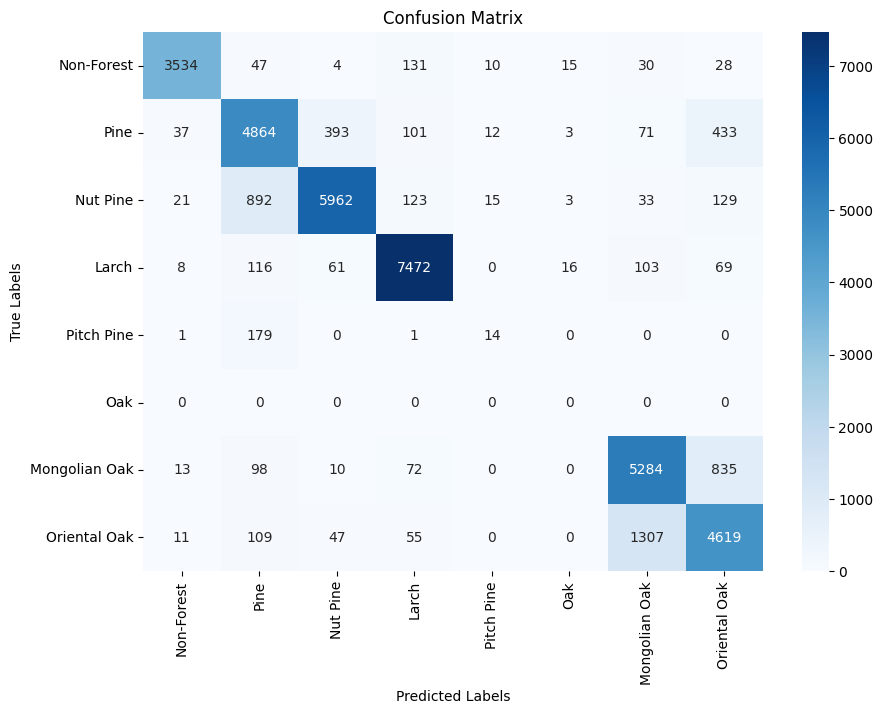

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.975     0.930     0.952      3799
         Pine      0.771     0.822     0.796      5914
     Nut Pine      0.920     0.831     0.873      7178
        Larch      0.939     0.952     0.946      7845
   Pitch Pine      0.275     0.072     0.114       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.774     0.837     0.804      6312
 Oriental Oak      0.756     0.751     0.753      6148

     accuracy                          0.849     37391
    macro avg      0.676     0.649     0.655     37391
 weighted avg      0.851     0.849     0.849     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI 추가

In [15]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi" #원천데이터 주소
bands = 5 #밴드 수

transform = get_transform(bands, scale_channels)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [18]:
input_channels = 5  # Number of input bands
stage_repeats = [3, 4, 7, 3]  
stage_channels = [12, 24, 48, 64]
model = VideoClassifier(input_channels, stage_repeats, stage_channels, num_classes=8)

model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [19]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video2_with_ndvi_30.pth")

Epoch 1/30 - Validation: 100%|██████████| 1169/1169 [01:34<00:00, 12.41it/s]



Epoch [1/30], Train Loss: 0.7256, Train Accuracy: 73.76%, Val Loss: 0.6176, Val Accuracy: 76.76%



Epoch 2/30 - Validation: 100%|██████████| 1169/1169 [01:26<00:00, 13.53it/s]



Epoch [2/30], Train Loss: 0.5045, Train Accuracy: 82.33%, Val Loss: 0.6414, Val Accuracy: 77.56%



Epoch 3/30 - Validation: 100%|██████████| 1169/1169 [01:26<00:00, 13.55it/s]


...


Epoch [28/30], Train Loss: 0.1748, Train Accuracy: 93.74%, Val Loss: 10.0604, Val Accuracy: 85.25%



Epoch 29/30 - Validation: 100%|██████████| 1169/1169 [01:20<00:00, 14.48it/s]



Epoch [29/30], Train Loss: 0.1726, Train Accuracy: 93.80%, Val Loss: 5.8142, Val Accuracy: 82.32%



Epoch 30/30 - Validation: 100%|██████████| 1169/1169 [01:21<00:00, 14.30it/s]



Epoch [30/30], Train Loss: 0.1687, Train Accuracy: 93.90%, Val Loss: 2.1742, Val Accuracy: 83.40%



### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [04:18<00:00, 14.45it/s]


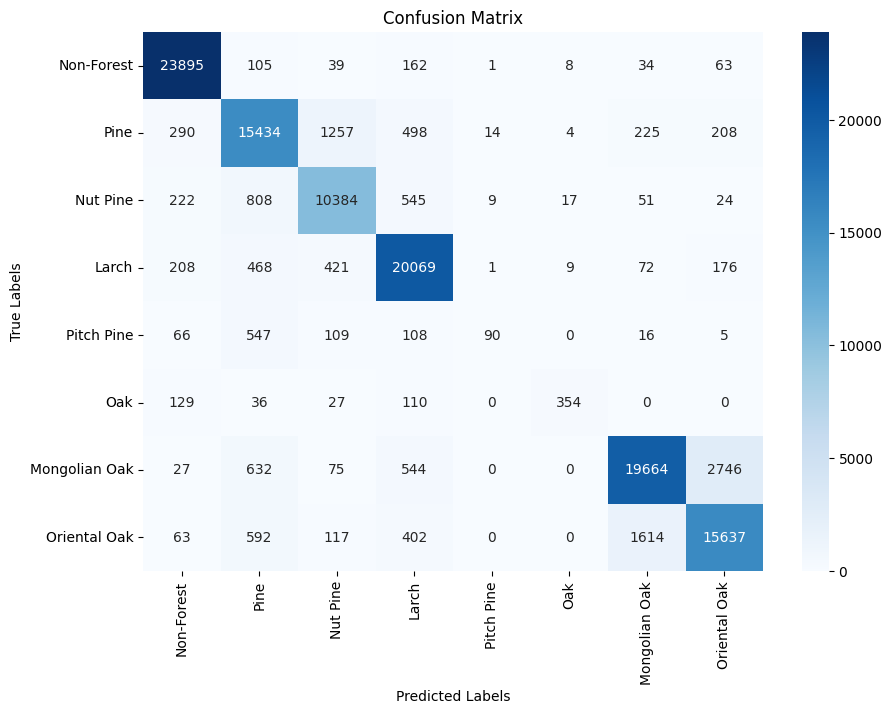

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.960     0.983     0.971     24307
         Pine      0.829     0.861     0.844     17930
     Nut Pine      0.835     0.861     0.848     12060
        Larch      0.894     0.937     0.915     21424
   Pitch Pine      0.783     0.096     0.170       941
          Oak      0.903     0.540     0.676       656
Mongolian Oak      0.907     0.830     0.867     23688
 Oriental Oak      0.829     0.849     0.839     18425

     accuracy                          0.884    119431
    macro avg      0.868     0.744     0.766    119431
 weighted avg      0.884     0.884     0.881    119431



In [20]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [01:20<00:00, 14.54it/s]


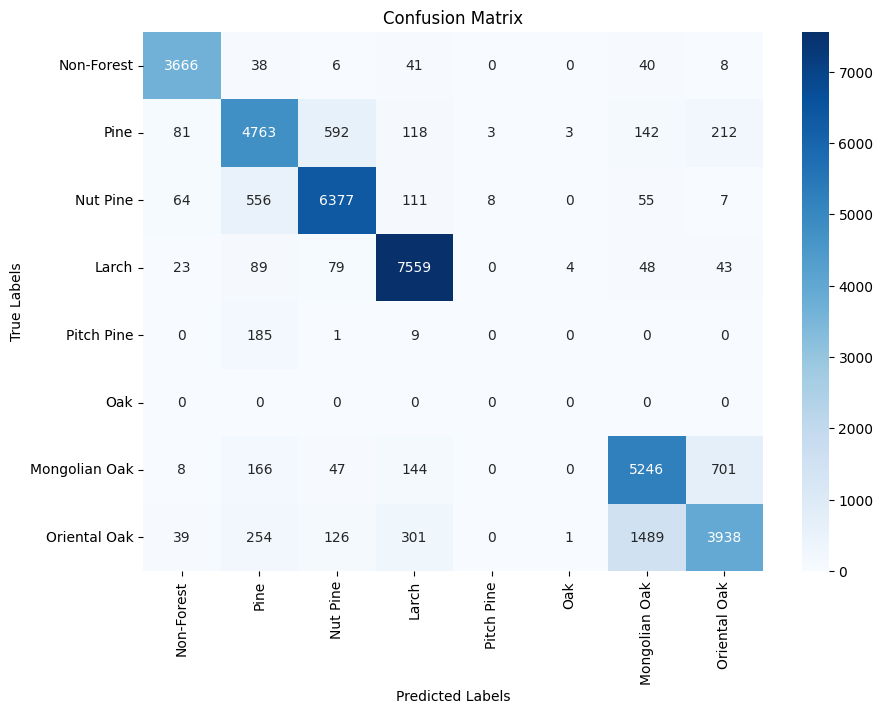

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.945     0.965     0.955      3799
         Pine      0.787     0.805     0.796      5914
     Nut Pine      0.882     0.888     0.885      7178
        Larch      0.913     0.964     0.937      7845
   Pitch Pine      0.000     0.000     0.000       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.747     0.831     0.787      6312
 Oriental Oak      0.802     0.641     0.712      6148

     accuracy                          0.844     37391
    macro avg      0.635     0.637     0.634     37391
 weighted avg      0.839     0.844     0.840     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI, Sentinel_2(B05, B06, B07, B11, B12) 데이터 추가

In [22]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi_s2" #원천데이터 주소
bands = 10 #밴드 수

transform = get_transform(bands, scale_channels)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [23]:
input_channels = 10 
stage_repeats = [4, 6, 10, 4]  
stage_channels = [16, 32, 64, 96]
model = VideoClassifier(input_channels, stage_repeats, stage_channels, num_classes=8)

model.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [24]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
model.load_state_dict(best_model_state)
torch.save(best_model_state, "./video2_with_ndvi_s2_30.pth")

Epoch 1/30 - Validation: 100%|██████████| 1169/1169 [02:45<00:00,  7.05it/s]



Epoch [1/30], Train Loss: 0.8317, Train Accuracy: 67.97%, Val Loss: 0.7683, Val Accuracy: 72.38%



Epoch 2/30 - Validation: 100%|██████████| 1169/1169 [02:30<00:00,  7.74it/s]



Epoch [2/30], Train Loss: 0.5417, Train Accuracy: 80.63%, Val Loss: 0.6238, Val Accuracy: 78.71%



Epoch 3/30 - Validation: 100%|██████████| 1169/1169 [02:30<00:00,  7.78it/s]


...


Epoch [15/30], Train Loss: 0.1778, Train Accuracy: 93.82%, Val Loss: 0.8885, Val Accuracy: 84.34%



Epoch 16/30 - Validation: 100%|██████████| 1169/1169 [02:35<00:00,  7.50it/s]



Epoch [16/30], Train Loss: 0.1733, Train Accuracy: 93.93%, Val Loss: 0.7597, Val Accuracy: 86.27%



Epoch 17/30 - Validation:  94%|█████████▍| 1099/1169 [02:26<00:09,  7.49it/s]


KeyboardInterrupt: 

### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [02:32<00:00, 24.52it/s]


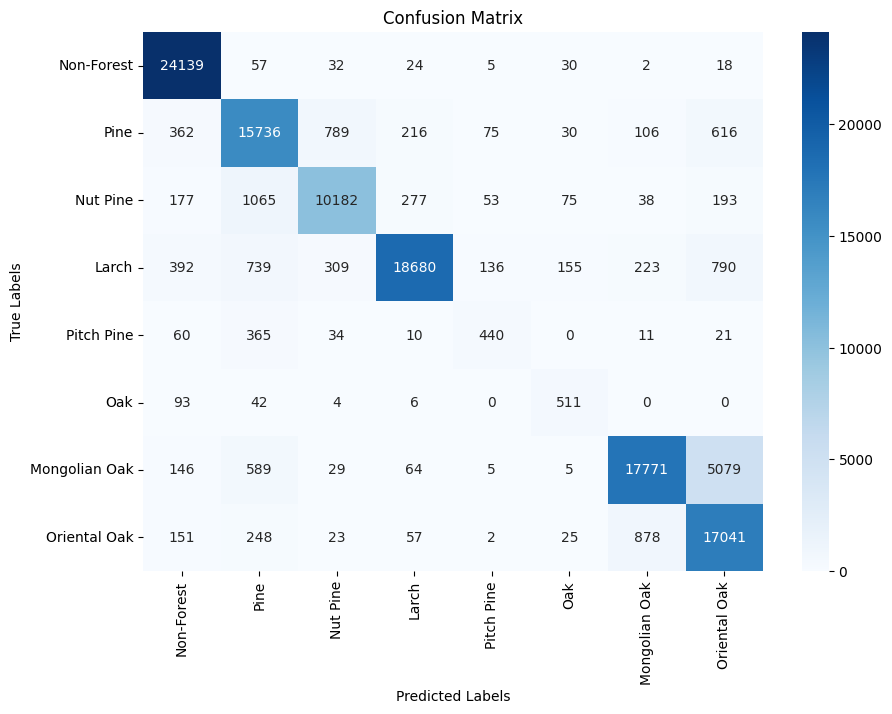

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.946     0.993     0.969     24307
         Pine      0.835     0.878     0.856     17930
     Nut Pine      0.893     0.844     0.868     12060
        Larch      0.966     0.872     0.917     21424
   Pitch Pine      0.615     0.468     0.531       941
          Oak      0.615     0.779     0.687       656
Mongolian Oak      0.934     0.750     0.832     23688
 Oriental Oak      0.717     0.925     0.808     18425

     accuracy                          0.875    119431
    macro avg      0.815     0.814     0.808    119431
 weighted avg      0.885     0.875     0.875    119431



In [23]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

val data

Evaluation Progress: 100%|██████████| 1169/1169 [00:47<00:00, 24.53it/s]


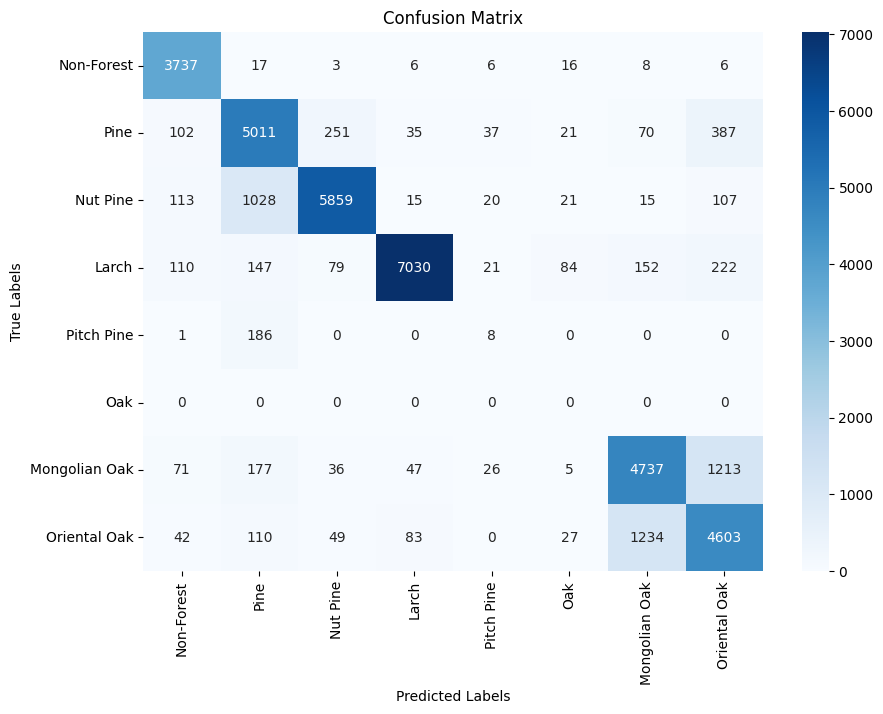

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.895     0.984     0.937      3799
         Pine      0.751     0.847     0.796      5914
     Nut Pine      0.933     0.816     0.871      7178
        Larch      0.974     0.896     0.934      7845
   Pitch Pine      0.068     0.041     0.051       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.762     0.750     0.756      6312
 Oriental Oak      0.704     0.749     0.726      6148

     accuracy                          0.829     37391
    macro avg      0.636     0.635     0.634     37391
 weighted avg      0.838     0.829     0.831     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
evaluate_model_with_cm(model, val_loader, num_classes=8)